# Inference with a Domain Wall Motion model using a simple CNN, compared to the built in MemTorch models
In this notebook, the results for my AI bachelor thesis are collected and the process is shown step by step.


## 1. Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import memtorch
from memtorch.mn.Module import patch_model
from memtorch.map.Parameter import naive_map
import copy
import gc
from collections import defaultdict
from torchvision.datasets import FashionMNIST
from memtorch.bh import Scheme, DomainWallMotion, Data_Driven, Stanford_PKU, VTEAM
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, ScalarFormatter



/home/booji/MemTorch/MemTorch/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Simple CNN
Here the CNN is defined, and then trained and tested using PyTorch, serving as a baseline accuracy.


In [9]:
class SimpleMNISTCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleMNISTCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(32*14*14, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32*14*14)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


def test_model(model, test_loader, device='cpu', max_batches=None):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            if max_batches and batch_idx >= max_batches:
                break
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
            if batch_idx % 10 == 0:
                gc.collect()
    return 100. * correct / total


def train_model(model, train_loader, test_loader, epochs=5, device='cpu'):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    best_acc = 0.0
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        scheduler.step()
        acc = test_model(model, test_loader, device=device)
        print(f"Epoch {epoch+1}: Test Accuracy: {acc:.2f}%")
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), 'mnist_cnn_best.pt')
    return model


device = 'cpu'
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_set = FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False)

model = SimpleMNISTCNN().to(device)
try:
    model.load_state_dict(torch.load('mnist_cnn_best.pt', map_location=device))
    print("Loaded pre-trained MNIST model.")
except:
    print("Training new MNIST model.")
    model = train_model(model, train_loader, test_loader, epochs=5, device=device)

start_time = time.time()
baseline_acc = test_model(model, test_loader, device=device)
print("Baseline testing time:", round(time.time()-start_time, 2))

print(f"Baseline Test Accuracy: {baseline_acc:.2f}%")

Loaded pre-trained MNIST model.
Baseline testing time: 1.58
Baseline Test Accuracy: 92.06%


## 3. Helper functions
These functions are used to get certain necessary values.

In [10]:
def limited_loader(loader, max_batches):
    for i, batch in enumerate(loader):
        if i >= max_batches:
            break
        yield batch


# Get the conductance value from the memristor model, can have different names depending on the model
def get_conductance(m):
    if hasattr(m, "memristance"):
        return 1.0 / m.memristance
    elif hasattr(m, "g"):
        return float(m.g)
    elif hasattr(m, "G"):
        return float(m.G)
    else:
        raise AttributeError("Unknown memristance or conductance value (not named memristance, g or G).")


# Get the float value of a parameter, by either getting the mean, sampling once or just using the original value
def get_float_value(p):
    if hasattr(p, "loc"):
        return p.loc
    elif callable(p):
        return p()
    else:
        return p


## 4. Model parameters
Definition of the parameters and model specific parameters.

In [8]:
tile_shape = (64,64)
ADC_resolution = 8
max_input_voltage = 0.1
n_pulses = 24
n_devices=50
n_repeats=100
nr_of_runs = 5
nr_of_energy_calculations = 100

DomainWallMotion_parameters = {
    'time_series_resolution': 1e-4,
    'r_off': memtorch.bh.StochasticParameter(loc=1e5, scale=15e3),
    'r_on': memtorch.bh.StochasticParameter(loc=1e3, scale=150),
    'L': memtorch.bh.StochasticParameter(loc=5000e-9, scale=300e-9),
    'w': memtorch.bh.StochasticParameter(loc=50e-9, scale=3e-9),
    't_free': memtorch.bh.StochasticParameter(loc=2.2e-9, scale=0.132e-9),
    'Delta': memtorch.bh.StochasticParameter(loc=10e-9, scale=1.2e-9),
    'M_s': memtorch.bh.StochasticParameter(loc=1050e3, scale=52.5e3),
    'Gilbert_damping': memtorch.bh.StochasticParameter(loc=0.006, scale=1.02e-3),
    'spin_polarization': memtorch.bh.StochasticParameter(loc=0.4, scale=0.032),
}

Data_Driven_parameters = {
    'time_series_resolution': 1e-4,
    'r_off': memtorch.bh.StochasticParameter(loc=17e3, scale=0.15 * 17e3),
    'r_on':  memtorch.bh.StochasticParameter(loc=1280, scale=0.15 * 1280),


    'A_p': memtorch.bh.StochasticParameter(loc=743.47, scale=0.10 * 743.47),
    'A_n': memtorch.bh.StochasticParameter(loc=-68012.28, scale=0.10 * abs(-68012.28)),


    'k_p': memtorch.bh.StochasticParameter(loc=5.11e-4, scale=0.10 * 5.11e-4),
    'k_n': memtorch.bh.StochasticParameter(loc=1.17e-3, scale=0.10 * 1.17e-3),
}

Stanford_PKU_parameters_stochastic = {
    'time_series_resolution': 1e-4,
    'r_off': memtorch.bh.StochasticParameter(loc=218586, scale=0.15 * 218586),
    'r_on':  memtorch.bh.StochasticParameter(loc=542, scale=0.15 * 542),

    'gap_init': memtorch.bh.StochasticParameter(loc=2e-10, scale=0.20 * 2e-10),
    'g_0': memtorch.bh.StochasticParameter(loc=0.25e-9, scale=0.10 * 0.25e-9),

    'V_0': memtorch.bh.StochasticParameter(loc=0.25, scale=0.10 * 0.25),
    'I_0': memtorch.bh.StochasticParameter(loc=1000e-6, scale=0.10 * 1000e-6),

    'R_th': memtorch.bh.StochasticParameter(loc=2.1e3, scale=0.15 * 2.1e3),
}

VTEAM_parameters = {
    'time_series_resolution': 1e-4,
    'r_off': memtorch.bh.StochasticParameter(loc=1000, scale=0.15 * 1000),
    'r_on':  memtorch.bh.StochasticParameter(loc=50, scale=0.15 * 50),

    'd': memtorch.bh.StochasticParameter(loc=3e-9, scale=0.10 * 3e-9),

    'k_on': memtorch.bh.StochasticParameter(loc=-10, scale=0.10 * abs(-10)),
    'k_off': memtorch.bh.StochasticParameter(loc=5e-4, scale=0.10 * 5e-4),

    'alpha_on': memtorch.bh.StochasticParameter(loc=3, scale=0.10 * 3),
    'alpha_off': memtorch.bh.StochasticParameter(loc=1, scale=0.10 * 1),
}

# The Stanford_PKU model does not allow StochasticParameters, so the parameters need to be converted back to floats
Stanford_PKU_parameters = {}
for k, v in Stanford_PKU_parameters_stochastic.items():
    if hasattr(v, "loc"):
        Stanford_PKU_parameters[k] = v.loc
    elif callable(v):
        Stanford_PKU_parameters[k] = v()
    else:
        Stanford_PKU_parameters[k] = v

## 5. Comparing device behaviour
Look at the hysteresis loop and bipolar switching behaviour.

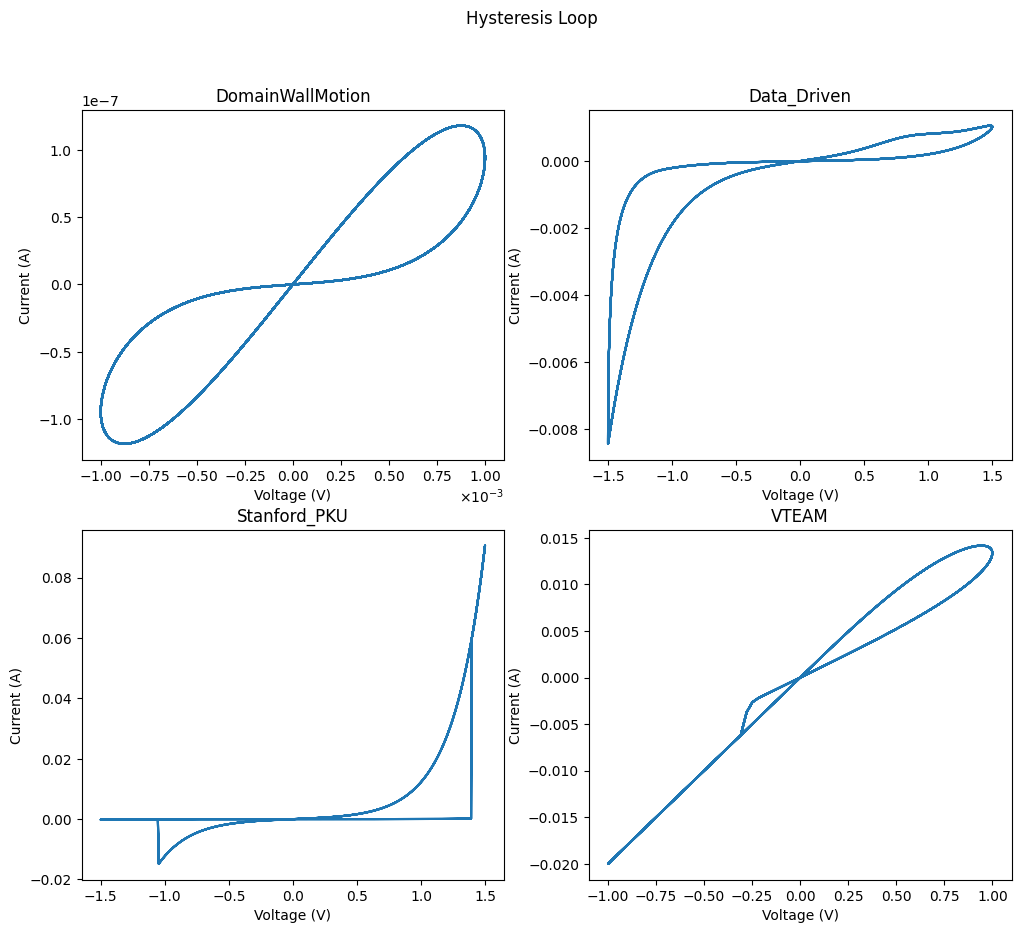

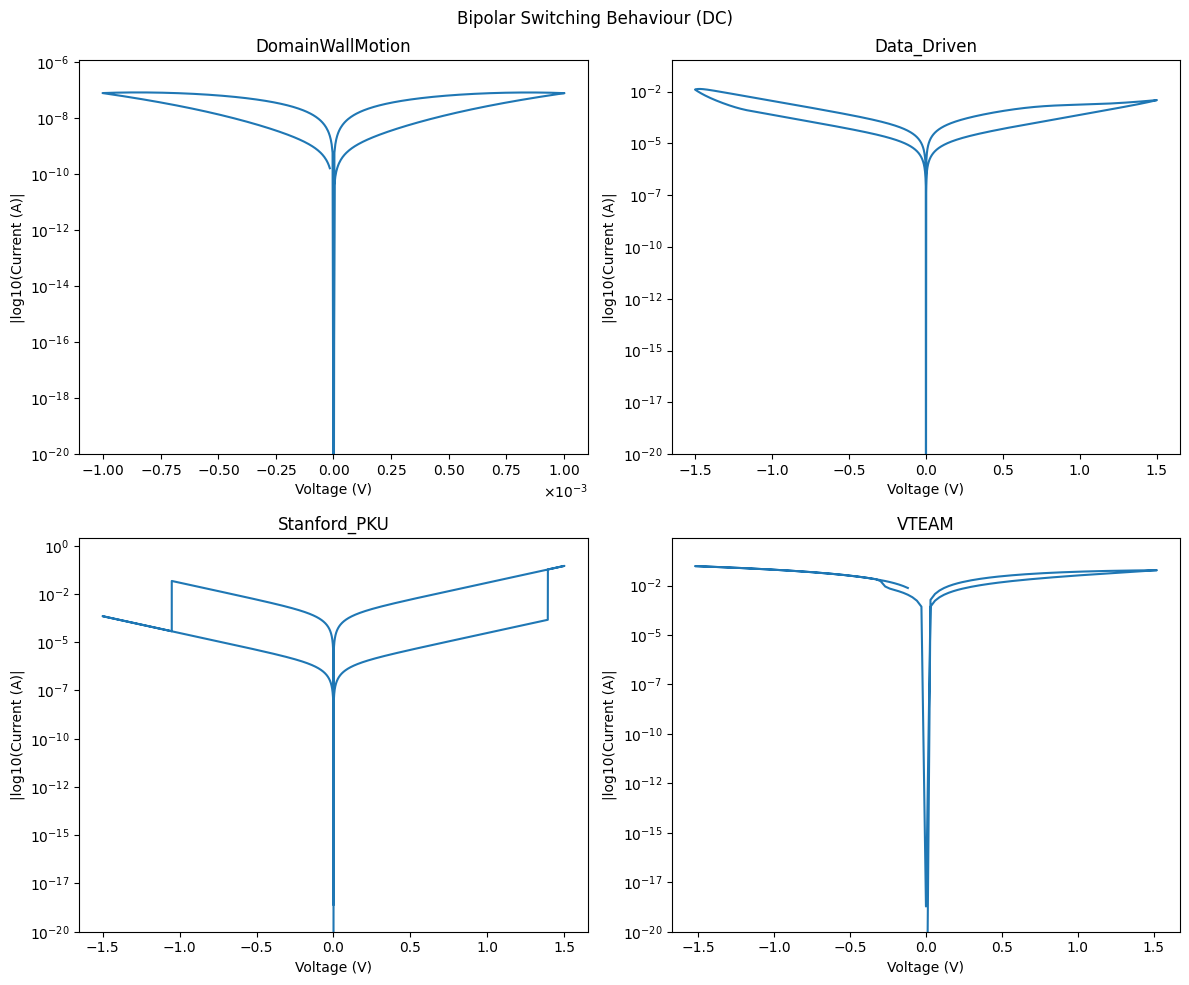

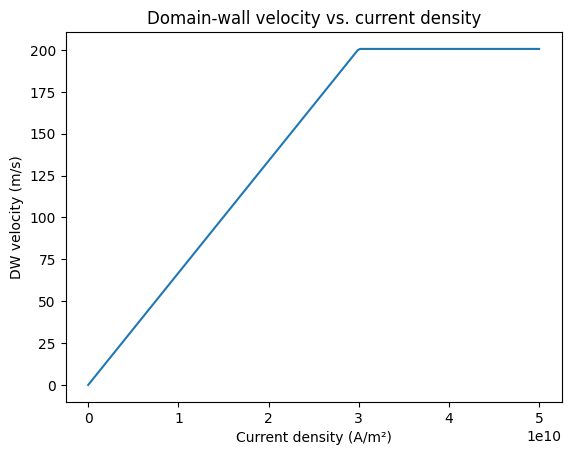

In [5]:
models_to_compare = [
    ('DomainWallMotion', DomainWallMotion),
    ('Data_Driven', Data_Driven),
    ('Stanford_PKU', Stanford_PKU),
    ('VTEAM', VTEAM),
]

def log_to_10(y, _):
    return rf"$10^{{{int(y)}}}$"

xformatter = ScalarFormatter(useMathText=True)
xformatter.set_powerlimits((-3, -3))

fig1, axes1 = plt.subplots(2, 2, figsize=(12, 10))
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))

for ax1, ax2, (name, memristor_model) in zip(axes1.flatten(), axes2.flatten(), models_to_compare):
    device_m = memristor_model()

    V_h, I_h = device_m.plot_hysteresis_loop(return_result=True)

    V_b, I_b = device_m.plot_bipolar_switching_behaviour(return_result=True)

    ax1.plot(V_h, I_h)
    ax1.set_title(f"{name}")
    ax1.set_xlabel("Voltage (V)")
    ax1.set_ylabel("Current (A)")
    if (memristor_model == DomainWallMotion):
        ax1.xaxis.set_major_formatter(xformatter)

    ax2.plot(V_b, np.log10(np.abs(I_b) + 1e-30))
    ax2.set_title(f"{name}")
    ax2.set_xlabel("Voltage (V)")
    ax2.set_ylabel("|log10(Current (A)|")
    ax2.set_ylim(-20, None)
    ax2.yaxis.set_major_formatter(FuncFormatter(log_to_10))
    if (memristor_model == DomainWallMotion):
        ax2.xaxis.set_major_formatter(xformatter)

fig1.suptitle("Hysteresis Loop")
fig2.suptitle("Bipolar Switching Behaviour (DC)")
plt.tight_layout()
plt.show()

device_m = DomainWallMotion()
Js = np.linspace(0, 5e10, 200)  # A/m²
vs = [device_m.speed(J) for J in Js]

plt.plot(Js, vs)
plt.xlabel("Current density (A/m²)")
plt.ylabel("DW velocity (m/s)")
plt.title("Domain-wall velocity vs. current density")
plt.show()

## 6. Patching and tuning the model
All memristor models used in this project are patched and tuned for testing and energy computations.

In [11]:
def patch_memristor_model(memristor_model, params, voltage=max_input_voltage):
    model_copy = copy.deepcopy(model)

    start_time = time.time()
    patched_model = patch_model(
        model_copy,
        memristor_model=memristor_model,
        memristor_model_params=params,
        module_parameters_to_patch=[nn.Conv2d, nn.Linear],
        mapping_routine=naive_map,
        transistor=True,
        scheme=Scheme.DoubleColumn,
        tile_shape=tile_shape,
        max_input_voltage=voltage,
        ADC_resolution=ADC_resolution,
        ADC_overflow_rate=0.05,
        quant_method='linear'
    )
    print("Patching time:", round(time.time()-start_time, 2))

    return patched_model


patched_DomainWallMotion_model = patch_memristor_model(DomainWallMotion, DomainWallMotion_parameters)
patched_DomainWallMotion_model.tune_(limited_loader(train_loader, 2))
patched_DomainWallMotion_model.eval()

patched_Data_Driven_model = patch_memristor_model(Data_Driven, Data_Driven_parameters)
patched_Data_Driven_model.tune_(limited_loader(train_loader, 2))
patched_Data_Driven_model.eval()

patched_Stanford_PKU_model = patch_memristor_model(Stanford_PKU, Stanford_PKU_parameters)
patched_Stanford_PKU_model.tune_(limited_loader(train_loader, 2))
patched_Stanford_PKU_model.eval()

patched_VTEAM_model = patch_memristor_model(VTEAM, VTEAM_parameters)
patched_VTEAM_model.tune_(limited_loader(train_loader, 2))
patched_VTEAM_model.eval()

Patched Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) -> bh.Conv2d(in_channels=1, out_channels=16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Patched Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) -> bh.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Patched Linear(in_features=6272, out_features=128, bias=True) -> bh.Linear(in_features=6272, out_features=128, bias=True)
Patched Linear(in_features=128, out_features=10, bias=True) -> bh.Linear(in_features=128, out_features=10, bias=True)
Patching time: 128.57
Tuned bh.Conv2d(in_channels=1, out_channels=16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)). Coefficient of determination: 0.979831 [7438.557617, -0.000043]
Tuned bh.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)). Coefficient of determination: 0.992413 [3995.567627, 0.000067]
Tuned bh.Linear(in_features=6272, out_features=128, bias=True). Coeffi

SimpleMNISTCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6272, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)

## 7. Pulse voltage and energy
Here the pulse voltage and inference energy are computed.

In [12]:
def compute_pulse_voltage(memristor_class, params, target_fraction=0.5, n_pulses=12):
    voltages = np.logspace(-7, 1, 6000)

    # Get the conductance range and calculate the target conductance change
    g_min = 1.0/get_float_value(params["r_off"])
    g_max = 1.0/get_float_value(params["r_on"])
    target_delta = target_fraction * (g_max-g_min)

    best_voltage = voltages[-1]

    # Apply n_pulses with voltage v and get the difference in conductance from the memristor model
    for v in voltages:
        m = memristor_class(**params)
        g_start = get_conductance(m)

        for _ in range(n_pulses):
            m.simulate(np.array([v]))

        g_end = get_conductance(m)
        delta_g = abs(g_end - g_start)
        if delta_g >= target_delta:
            best_voltage = v
            break

    return best_voltage


def compute_macs_from_forward(model_check, input_shape=(1, 1, 28, 28)):
    macs = {}
    hooks = []

    def conv_hook(name):
        def hook(m, x, y):
            B, Cin, Hin, Win = x[0].shape
            Cout, Hout, Wout = y.shape[1:]
            kh, kw = m.kernel_size
            macs[name] = Cout * Hout * Wout * Cin * kh * kw
        return hook

    def linear_hook(name):
        def hook(m, x, y):
            macs[name] = m.in_features * m.out_features
        return hook

    for name, m in model_check.named_modules():
        if isinstance(m, nn.Conv2d):
            hooks.append(m.register_forward_hook(conv_hook(name)))
        elif isinstance(m, nn.Linear):
            hooks.append(m.register_forward_hook(linear_hook(name)))

    model_check.eval()
    with torch.no_grad():
        dummy = torch.zeros(input_shape)
        model_check(dummy)

    for h in hooks:
        h.remove()

    return sum(macs.values())


def compute_inference_energy(patched_model, memristor_params, max_input_voltage=0.3, time_resolution=100e-9):

    layer_energy = {}
    total_energy = 0.0

    for name, module in patched_model.named_modules():
        if hasattr(module, "weight") and isinstance(module.weight, torch.Tensor):
            W = module.weight.detach().cpu()
            if isinstance(module, torch.nn.Conv2d):
                Cout, Cin, kh, kw = W.shape
                W_mat = W.view(Cout, Cin * kh * kw)
            else:
                W_mat = W.view(W.shape[0], -1)

            r_on = get_float_value(memristor_params["r_on"])
            r_off = get_float_value(memristor_params["r_off"])

            G_pos, G_neg = naive_map(
                W_mat,
                r_on=r_on,
                r_off=r_off,
                scheme=module.scheme,
                p_l=None
            )

            energy_layer = 0.0

            for G_mat in [G_pos, G_neg]:
                G = G_mat.cpu().numpy().flatten()
                energy_layer += (max_input_voltage**2) * np.sum(G) * time_resolution

            layer_energy[name] = energy_layer
            total_energy += energy_layer

    energy_per_mac = total_energy/compute_macs_from_forward(model)

    return total_energy, energy_per_mac, layer_energy


def print_energy_data(memristor_class, patched_model, params):
    pulse_voltages = []
    inference_energies = []
    for _ in range(nr_of_energy_calculations):
        pulse_voltages.append(compute_pulse_voltage(memristor_class, params))
        _, inference_energy, _  = compute_inference_energy(patched_model, params)
        inference_energies.append(inference_energy)

    print(f"Pulse voltage: {np.mean(pulse_voltages)*1e3:.3f} mV +/- {np.std(pulse_voltages)*1e3:.3f} mV")
    print(f"Energy per MAC: {np.mean(inference_energies)*1e15:.3f} fJ/MAC +/- {np.std(inference_energies)*1e15:.3f} fJ/MAC")

print("DomainWallMotion:")
print_energy_data(DomainWallMotion, patched_DomainWallMotion_model, DomainWallMotion_parameters)

print("Data_Driven:")
print_energy_data(Data_Driven, patched_Data_Driven_model, Data_Driven_parameters)

print("Stanford_PKU:")
print_energy_data(Stanford_PKU, patched_Stanford_PKU_model, Stanford_PKU_parameters)

print("VTEAM:")
print_energy_data(VTEAM, patched_VTEAM_model, VTEAM_parameters)

DomainWallMotion:
Pulse voltage: 0.532 mV +/- 0.085 mV
Energy per MAC: 157.289 fJ/MAC +/- 20.824 fJ/MAC
Data_Driven:
Pulse voltage: 8.197 mV +/- 4.166 mV
Energy per MAC: 281.805 fJ/MAC +/- 31.899 fJ/MAC
Stanford_PKU:
Pulse voltage: 488.782 mV +/- 0.000 mV
Energy per MAC: 265.464 fJ/MAC +/- 0.000 fJ/MAC
VTEAM:
Pulse voltage: 20.055 mV +/- 0.000 mV
Energy per MAC: 5684.945 fJ/MAC +/- 735.065 fJ/MAC


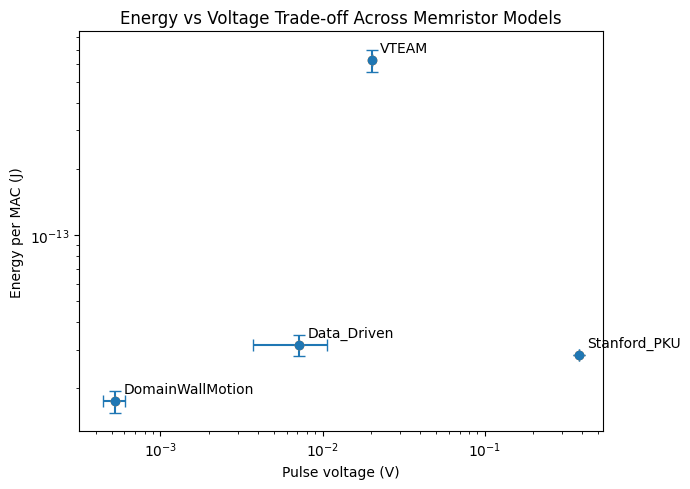

In [8]:
models = ["DomainWallMotion", "Data_Driven", "Stanford_PKU", "VTEAM"]

pulse_voltage_mV = np.array([0.524, 7.196, 381.151, 20.055])
energy_fJ = np.array([17.450, 31.639, 28.382, 628.044])

voltage_std = np.array([0.084, 3.495, 0.0, 0.006]) * 1e-3
energy_std = np.array([1.983, 3.528, 0.0, 72.940]) * 1e-15

pulse_voltage = pulse_voltage_mV * 1e-3
energy = energy_fJ * 1e-15

plt.figure(figsize=(7, 5))


plt.errorbar(pulse_voltage, energy, xerr=voltage_std, yerr=energy_std, fmt='o',capsize=4)

plt.loglog(pulse_voltage, energy, 'o')

for x, y, label in zip(pulse_voltage, energy, models):
    plt.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=10
    )

plt.xlabel("Pulse voltage (V)")
plt.ylabel("Energy per MAC (J)")
plt.title("Energy vs Voltage Trade-off Across Memristor Models")

plt.tight_layout()
plt.show()

## 8. Device metrics
The device aware metrics like non linearity are gathered here.

ΔG1 per device: [9.46375215e-06 7.76498724e-06 8.68303170e-06 1.15437415e-05
 8.14196398e-06 8.79116904e-06 8.63423812e-06 8.14446584e-06
 7.95182721e-06 8.45841740e-06 9.61344191e-06 8.20534830e-06
 8.35710768e-06 8.53149454e-06 9.51220912e-06 9.00781554e-06
 7.99572205e-06 7.98020841e-06 8.89007741e-06 1.00168354e-05
 9.80914608e-06 8.66383774e-06 1.00817675e-05 8.21784135e-06
 7.53900658e-06 9.19998225e-06 8.71948775e-06 7.78474538e-06
 9.02824257e-06 9.04600282e-06 9.22092186e-06 9.41442393e-06
 8.79493408e-06 9.00525874e-06 9.64635331e-06 8.64024904e-06
 1.07148678e-05 9.31657163e-06 7.89688242e-06 1.05522061e-05
 9.03316421e-06 9.27803998e-06 8.50597957e-06 9.59901071e-06
 8.97457416e-06 7.24153825e-06 7.69048308e-06 9.39356771e-06
 9.02994466e-06 9.00614744e-06]
ΔG2 per device: [6.48748316e-05 5.20744312e-05 5.04545844e-05 7.24859865e-05
 4.77473806e-05 6.35877043e-05 5.88691600e-05 5.20103057e-05
 5.52896959e-05 5.37619721e-05 5.17702460e-05 4.79578633e-05
 4.89197655e-05 4.531

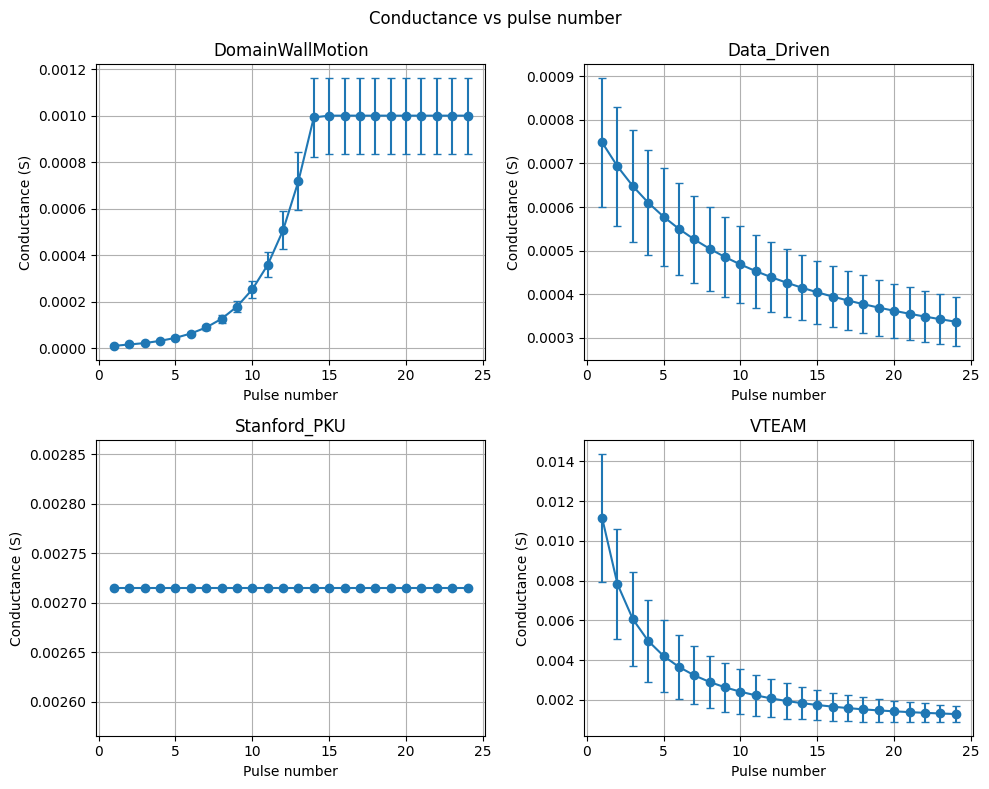

In [9]:
def measure_metrics(memristor_class, params):
    delta_g1 = []
    delta_g2 = []
    per_device_var = []
    per_device_cv = []

    for _ in range(n_devices):
        device_params = {k: (v() if callable(v) else v) for k, v in params.items()}
        pulse_voltage = compute_pulse_voltage(memristor_class, device_params)

        dg1 = []
        dg2 = []

        for _ in range(n_repeats):
            m = memristor_class(**device_params)
            g = []

            for _ in range(int(n_pulses/2)):
                m.simulate(np.array([pulse_voltage]))
                g.append(get_conductance(m))

            early_idx = slice(0, 5)
            late_idx = slice(int(0.3*n_pulses), int(0.3*n_pulses)+2)

            dg1.append(abs(np.mean(np.diff(g[early_idx]))))
            dg2.append(abs(np.mean(np.diff(g[late_idx]))))

        delta_g1.append(np.mean(dg1))
        delta_g2.append(np.mean(dg2))
        per_device_var.append(0.5 * (np.var(dg1) + np.var(dg2)))

        if np.mean(dg2) > 0:
            per_device_cv.append(0.5 * (np.std(dg1) + np.std(dg2)) / 0.5 * (np.mean(dg1) + np.mean(dg2)))
        else:
            per_device_cv.append(0)

    delta_g1 = np.array(delta_g1)
    delta_g2 = np.array(delta_g2)

    NL = np.mean(delta_g2 / (np.mean(delta_g1) + 1e-30))
    device_to_device = np.var(delta_g1)
    if (np.mean(delta_g1)):
        device_to_device_cv = np.std(delta_g1) / np.mean(delta_g1)
    else:
        device_to_device_cv = 0

    per_device = np.mean(per_device_var)
    per_device_cv_mean = np.mean(per_device_cv)

    print(f"ΔG1 per device: {delta_g1}")
    print(f"ΔG2 per device: {delta_g2}")
    print(f"NL: {NL:.3f}")
    print(f"Device-to-device variance: {device_to_device:.3e}")
    print(f"Device-to-device CV: {device_to_device_cv * 100:.2f} %")
    print(f"Per-device variance: {per_device:.3e}")
    print(f"Per-device CV: {per_device_cv_mean * 100:.2f} %")

    return pulse_voltage, NL, device_to_device, per_device


models_to_compare = [
    ('DomainWallMotion', DomainWallMotion, DomainWallMotion_parameters),
    ('Data_Driven', Data_Driven, Data_Driven_parameters),
    ('Stanford_PKU', Stanford_PKU, Stanford_PKU_parameters),
    ('VTEAM', VTEAM, VTEAM_parameters),
]

for name, m_model, params in models_to_compare:
    measure_metrics(m_model, params)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (name, memristor_model, params) in zip(axes, models_to_compare):
    trajectories = []

    for _ in range(n_devices):
        device_params = {k: (v() if callable(v) else v) for k, v in params.items()}
        pulse_voltage = compute_pulse_voltage(memristor_model, device_params)

        m = memristor_model(**device_params)
        g = []

        for _ in range(n_pulses):
            m.simulate(np.array([pulse_voltage]))
            g.append(get_conductance(m))

        trajectories.append(g)

    trajectories = np.array(trajectories)

    mean_g = trajectories.mean(axis=0)
    std_g = trajectories.std(axis=0)

    ax.errorbar(
        np.arange(1, n_pulses + 1),
        mean_g,
        yerr=std_g,
        marker='o',
        capsize=3
    )

    ax.set_title(name)
    ax.set_xlabel("Pulse number")
    ax.set_ylabel("Conductance (S)")
    ax.grid(True)

plt.suptitle("Conductance vs pulse number")
plt.tight_layout()
plt.show()

## 9. Test accuracy
All models are patched and tested five times, reporting testing times and accuracy. Afterwards, one tuned test is reported.

In [10]:
def test_loop(memristor_model, params):
    accuracies = []
    testing_times = []
    for _ in range(nr_of_runs):
        voltage = float(compute_pulse_voltage(memristor_model, params))
        print(voltage)
        patched_model = patch_memristor_model(memristor_model, params, voltage)
        start_time = time.time()
        patched_model.tune_(limited_loader(train_loader, 2))
        print("Tuning time:", round(time.time()-start_time, 2))
        patched_model.eval()
        start_time = time.time()
        patched_acc = test_model(patched_model, test_loader, device=device)
        accuracies.append(patched_acc)
        testing_times.append(round(time.time()-start_time, 2))
        print("Testing time:", round(time.time()-start_time, 2))
        accuracy_drop = baseline_acc - patched_acc
        print(f"Accuracy drop: {accuracy_drop:.2f}%")

    print("Final results for this model: ")
    print(f"Accuracy: {np.mean(accuracies):.2f}% +/- {np.std(accuracies):.2f}%")
    print(f"Testing time: {np.mean(testing_times):.2f} s +/- {np.std(testing_times):.2f} s")


print("DomainWallMotion:")
test_loop(DomainWallMotion, DomainWallMotion_parameters)

print("Data_Driven:")
test_loop(Data_Driven, Data_Driven_parameters)

print("Stanford_PKU:")
test_loop(Stanford_PKU, Stanford_PKU_parameters)

print("VTEAM:")
test_loop(VTEAM, VTEAM_parameters)

DomainWallMotion:
0.0005452840199347846
Patched Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) -> bh.Conv2d(in_channels=1, out_channels=16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Patched Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) -> bh.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Patched Linear(in_features=6272, out_features=128, bias=True) -> bh.Linear(in_features=6272, out_features=128, bias=True)
Patched Linear(in_features=128, out_features=10, bias=True) -> bh.Linear(in_features=128, out_features=10, bias=True)
Patching time: 128.64
Tuned bh.Conv2d(in_channels=1, out_channels=16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)). Coefficient of determination: 0.976687 [1095556.875000, 0.000274]
Tuned bh.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)). Coefficient of determination: 0.989775 [823351.375000, 0.000222]
Tuned bh.Linear(in_feature

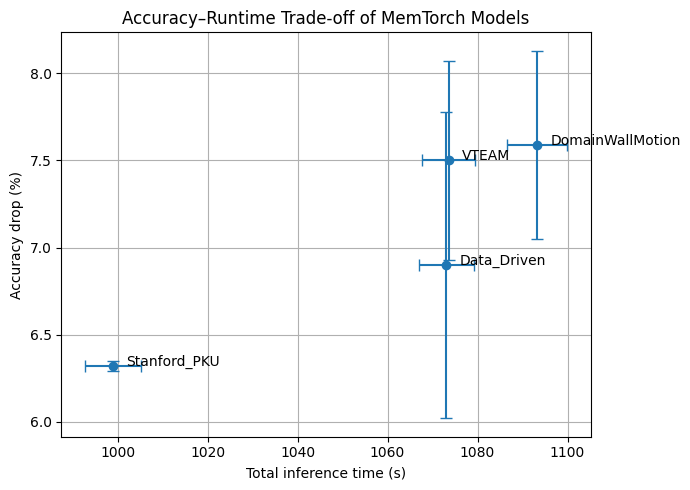

In [4]:
models = ["DomainWallMotion", "Data_Driven", "Stanford_PKU", "VTEAM"]

patch = np.array([127.79, 98.55, 43.72, 105.26])
tune  = np.array([20.17, 20.55, 20.16, 19.99])
test  = np.array([945.28, 954.00, 935.13, 948.36])

patch_std = np.array([0.55, 1.28, 0.44, 0.95])
tune_std  = np.array([0.14, 0.38, 0.16, 0.32])
test_std  = np.array([6.62, 5.91, 6.14, 5.83])

acc_drop = np.array([7.59, 6.90, 6.32, 7.50])
acc_std  = np.array([0.54, 0.88, 0.03, 0.57])

total_time = patch + tune + test
total_std  = np.sqrt(patch_std**2 + tune_std**2 + test_std**2)

plt.figure(figsize=(7,5))
plt.errorbar(
    total_time, acc_drop,
    xerr=total_std, yerr=acc_std,
    fmt='o', capsize=4
)

for i, m in enumerate(models):
    plt.text(total_time[i] + 3, acc_drop[i], m)

plt.xlabel("Total inference time (s)")
plt.ylabel("Accuracy drop (%)")
plt.title("Accuracy–Runtime Trade-off of MemTorch Models")
plt.grid(True)
plt.tight_layout()
plt.show()